# Centralized Training for MHEALTH Dataset

This notebook implements centralized training for the MHEALTH dataset to establish baseline performance.

## Objectives:
- Load and preprocess the MHEALTH dataset
- Train a centralized model with optimized hyperparameters
- Evaluate model performance and establish baseline accuracy
- Compare with federated learning results

## Key Features:
- EfficientNet architecture optimized for sensor data
- Advanced learning rate scheduling with warmup and cosine decay
- Comprehensive evaluation metrics
- Model checkpointing and visualization


In [ ]:
# ============================================================================
# GOOGLE COLAB SETUP CELL - COPY THIS INTO EACH NOTEBOOK AS CELL 1
# ============================================================================

"""
Google Colab Environment Setup and Optimization

This cell handles the complete initialization of the Colab environment for machine learning experiments.
It performs hardware detection, package installation, file verification, and creates helper functions
for session management. The setup is optimized for both free and pro Colab instances.

Key functionalities:
- Google Drive mounting and navigation to project directory
- Automatic hardware detection and configuration optimization
- Required package installation (Opacus, MLflow, etc.)
- File system verification for all project dependencies
- Environment variable configuration for optimal performance
- Helper functions for session management and file operations
"""

# Mount Google Drive and setup environment
from google.colab import drive
import os
import torch
import time

print("Setting up Google Colab environment...")

# 1. Mount Google Drive
drive.mount('/content/drive')
print("Google Drive mounted successfully!")

# 2. Navigate to project directory
project_path = '/content/drive/MyDrive/Privacy_ML_Project'
try:
    os.chdir(project_path)
    print(f"Navigated to: {os.getcwd()}")
except FileNotFoundError:
    print(f"Project folder not found: {project_path}")
    print("Please create 'Privacy_ML_Project' folder in your Google Drive and upload all files!")
    raise

# 3. Install required packages for differential privacy and machine learning
print("Installing required packages...")
!pip install -q opacus mlflow seaborn scikit-learn tqdm typing-extensions

# 4. Verify all required project files exist
required_files = [
    'dataset_loader.py', 'models.py', 'training_utils.py',
    'dp_utils.py', 'partitioning.py', 'logging_utils.py'
]

missing_files = [f for f in required_files if not os.path.exists(f)]
if missing_files:
    print(f"Missing files: {missing_files}")
    print("Please upload all .py files to your Google Drive!")
else:
    print("All required Python modules found!")

# 5. Check MHEALTH dataset availability and integrity
if os.path.exists('MHEALTHDATASET'):
    dataset_files = os.listdir('MHEALTHDATASET')
    print(f"MHEALTH dataset found! ({len(dataset_files)} files)")
    if len(dataset_files) < 10:
        print("Warning: Expected 10 subject files, found", len(dataset_files))
else:
    print("MHEALTH dataset not found!")
    print("Please upload the 'MHEALTHDATASET' folder to your Google Drive!")

# 6. Hardware detection and automatic optimization configuration
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_memory = torch.cuda.get_device_properties(0).total_memory // 1024**3

    # Configure training parameters based on detected GPU type
    if 'T4' in gpu_name:
        # Free Colab T4 - moderate batch sizes to avoid memory issues
        COLAB_BATCH_SIZE = 512
        COLAB_EPOCHS = 8
        print(f"GPU DETECTED: {gpu_name} ({gpu_memory}GB)")
        print("Optimized for Colab Free (T4 GPU)")
    else:
        # Colab Pro V100/A100 - higher batch sizes for faster training
        COLAB_BATCH_SIZE = 1024
        COLAB_EPOCHS = 6
        print(f"HIGH-END GPU: {gpu_name} ({gpu_memory}GB)")
        print("Optimized for Colab Pro")

    # Enable CUDA optimizations for better performance
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.enabled = True

else:
    # CPU fallback configuration with reduced batch sizes
    COLAB_BATCH_SIZE = 256
    COLAB_EPOCHS = 6
    print("No GPU detected - using CPU")
    print("Consider: Runtime → Change runtime type → GPU")

# 7. Set environment variables for improved training performance
os.environ['PYTHONUNBUFFERED'] = '1'  # Enable immediate output for real-time monitoring
os.environ['CUDA_LAUNCH_BLOCKING'] = '0'  # Enable asynchronous CUDA operations

# 8. Create directory structure for storing results
results_dir = 'colab_results'
os.makedirs(results_dir, exist_ok=True)
print(f"Results will be saved to: {results_dir}/")

# 9. Define utility functions for Colab session management
def colab_keep_alive():
    """
    Session timeout prevention function
    Call periodically during long training runs to maintain Colab connection
    """
    print(f"Training active... {time.strftime('%H:%M:%S')}")

def colab_save_results():
    """
    Automated backup function for all generated artifacts
    Saves model files, plots, logs, and other outputs to results directory
    Returns list of successfully saved files
    """
    import glob
    import shutil

    patterns = ['*.pth', '*.png', '*.csv', '*.txt']
    saved_files = []

    for pattern in patterns:
        for file in glob.glob(pattern):
            try:
                shutil.copy2(file, f"{results_dir}/{file}")
                saved_files.append(file)
            except Exception as e:
                print(f"Warning: Could not save {file}: {e}")

    if saved_files:
        print(f"Saved {len(saved_files)} files to {results_dir}/")
        return saved_files
    else:
        print("No result files found to save")
        return []

def colab_download_file(filename):
    """
    Direct download function for individual files
    Downloads specified file to user's local machine through browser
    """
    from google.colab import files
    try:
        files.download(filename)
        print(f"Downloaded: {filename}")
    except Exception as e:
        print(f"Could not download {filename}: {e}")

# 10. Display final configuration summary
print("\n" + "="*60)
print("OPTIMIZED COLAB CONFIGURATION")
print("="*60)
print(f"Device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
print(f"Recommended Batch Size: {COLAB_BATCH_SIZE}")
print(f"Recommended Epochs: {COLAB_EPOCHS}")
print(f"Project Directory: {os.getcwd()}")
print(f"Results Directory: {results_dir}/")
print("="*60)

print("\nSetup complete! You can now run your notebook cells.")
print("\nUSAGE TIPS:")
print("   • Use COLAB_BATCH_SIZE and COLAB_EPOCHS in your configuration")
print("   • Call colab_keep_alive() in long training loops")
print("   • Use colab_save_results() to backup your files")
print("   • Use colab_download_file('filename') to download results")

# Set global variables for use throughout the notebook
globals()['BATCH_SIZE'] = COLAB_BATCH_SIZE
globals()['NUM_EPOCHS'] = COLAB_EPOCHS
globals()['FED_ROUNDS'] = COLAB_EPOCHS  # For federated learning compatibility

Setting up Google Colab environment...
Mounted at /content/drive
Google Drive mounted successfully!
Navigated to: /content/drive/MyDrive/Privacy_ML_Project
Installing required packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.4/254.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

In [ ]:
"""
Import Dependencies and Initialize Environment

This cell imports all necessary libraries and custom modules for centralized training.
It includes standard deep learning libraries, visualization tools, and project-specific
utilities for data loading, model creation, and training management.

Key components:
- PyTorch for deep learning operations and GPU computation
- NumPy for numerical operations and array manipulation
- Matplotlib/Seaborn for data visualization and result plotting
- Scikit-learn for evaluation metrics and classification reports
- Custom modules for dataset handling, model architectures, and training utilities
"""

# Standard library imports
import os
import numpy as np
import time
import warnings

# Deep learning framework imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

# Visualization and analysis libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

# Suppress warnings for cleaner output during training
warnings.filterwarnings('ignore')

# Project-specific custom modules for centralized training workflow
from dataset_loader import create_data_loaders
from models import get_model, count_parameters
from training_utils import (
    set_seed, get_optimizer, get_lr_scheduler, train_epoch,
    evaluate_model, plot_training_history, plot_confusion_matrix,
    save_model, get_device, print_model_info
)

# Configure visualization styling for professional plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [ ]:
"""
Training Configuration and Hyperparameter Setup

This cell defines all hyperparameters and training configuration settings optimized
for high accuracy on the MHEALTH dataset. The configuration balances training speed
with model performance to achieve target accuracy of 85-86%.

Key hyperparameters:
- Batch size optimized for memory efficiency and convergence speed
- Learning rate tuned for stable yet fast convergence
- Regularization parameters balanced to prevent overfitting while maintaining capacity
- Advanced training techniques like gradient clipping and label smoothing
"""

# Dataset and file path configuration
DATA_PATH = 'MHEALTHDATASET'
MODEL_SAVE_PATH = 'centralized_mhealth_model.pth'
PLOT_SAVE_PATH = 'centralized_training_history.png'

# Core training hyperparameters optimized for performance
BATCH_SIZE = 256  # Larger batch size for faster training with fewer iterations
LEARNING_RATE = 0.004  # Higher learning rate for faster convergence
WEIGHT_DECAY = 0.003  # Reduced weight decay to allow more model capacity
NUM_EPOCHS = 10  # Optimized epoch count for efficiency while maintaining accuracy

# Reproducibility and device setup
RANDOM_SEED = 42
set_seed(RANDOM_SEED)
device = get_device()

# Advanced training optimization settings
GRADIENT_CLIP_VALUE = 0.5  # Gradient clipping to prevent gradient explosion
LABEL_SMOOTHING = 0.1  # Label smoothing for improved generalization
MIN_LR = 1e-6  # Minimum learning rate floor for cosine annealing scheduler

print(f"Using device: {device}")
print(f"Optimized configuration loaded for {NUM_EPOCHS} epochs")

Using device: cpu
Optimized configuration loaded for 10 epochs


In [ ]:
"""
Dataset Loading and Preparation

This cell loads the MHEALTH dataset and creates PyTorch data loaders for training and testing.
The dataset contains sensor readings from mobile health devices across multiple activity classes.
Data is split into training and testing sets with appropriate preprocessing.

Dataset characteristics:
- Multi-class activity recognition from sensor data
- Train/test split with stratified sampling
- Batch processing optimized for the configured batch size
- Zero workers for compatibility across different environments
"""

print("Loading MHEALTH dataset...")

# Create data loaders with optimized configuration
train_loader, test_loader, dataset_info = create_data_loaders(
    data_path=DATA_PATH,
    batch_size=BATCH_SIZE,
    test_size=0.2,  # 80/20 train-test split
    random_state=RANDOM_SEED,
    num_workers=0,  # Single-threaded loading for stability
)

# Display dataset statistics and verify successful loading
print("Dataset loaded successfully!")
print(f"Training samples: {dataset_info['train_samples']}")
print(f"Test samples: {dataset_info['test_samples']}")
print(f"Number of classes: {dataset_info['num_classes']}")
print(f"Number of features: {dataset_info['num_features']}")


Loading MHEALTH dataset...
Loaded 1215745 samples with 13 classes
Dataset Info:
  Features: 23
  Classes: 13
  Train samples: 972596
  Test samples: 243149
  Class distribution: [872550  30720  30720  30720  30720  30720  28315  29441  29337  30720
  30720  30720  10342]
Dataset loaded successfully!
Training samples: 972596
Test samples: 243149
Number of classes: 13
Number of features: 23


In [ ]:
"""
Model Architecture Creation and Initialization

This cell creates the EfficientNet model architecture optimized for the MHEALTH dataset.
The model uses enhanced configuration with increased hidden dimensions and optimized
dropout rates to balance capacity and generalization. The architecture is specifically
tuned for multi-class activity classification from sensor data.

Model optimizations:
- EfficientNet backbone for efficient parameter usage
- Increased hidden dimension (256) for better feature representation
- Reduced dropout (0.2) to maintain model capacity while preventing overfitting
- Architecture sized appropriately for the 23-feature input and 13-class output
"""

print("Creating optimized model...")

# Initialize EfficientNet model with enhanced configuration
model = get_model(
    model_name='efficientnet',
    input_dim=dataset_info['num_features'],
    hidden_dim=256,  # Increased capacity for better feature learning
    num_classes=dataset_info['num_classes'],
    dropout_rate=0.2  # Reduced dropout for more model capacity
)

# Move model to appropriate device (GPU/CPU) and display architecture info
model = model.to(device)
print_model_info(model, input_size=(BATCH_SIZE, dataset_info['num_features']))

# Display comprehensive model configuration summary
print(f"\n=== Optimized Model Created ===")
print(f"Model: EfficientNet (Enhanced)")
print(f"Parameters: {count_parameters(model):,}")
print(f"Hidden dimension: 256 (increased from baseline)")
print(f"Dropout rate: 0.2 (optimized for capacity retention)")
print(f"Input features: {dataset_info['num_features']}")
print(f"Output classes: {dataset_info['num_classes']}")

Creating optimized model...
Model: EfficientNet
Total parameters: 181,645
Input size: (256, 23)
Output size: torch.Size([256, 13])
Device: cpu

=== Optimized Model Created ===
Model: EfficientNet (Enhanced)
Parameters: 181,645
Hidden dimension: 256 (increased from 128)
Dropout rate: 0.2 (reduced from 0.3)
Input features: 23
Output classes: 13


In [ ]:
"""
Training Components Setup and Optimization

This cell configures all training components including loss function, optimizer, and 
learning rate scheduler. The setup uses advanced techniques like label smoothing,
AdamW optimization, and warmup cosine annealing for improved training dynamics.

Key training components:
- CrossEntropyLoss with label smoothing for better generalization
- AdamW optimizer for superior weight decay handling
- Warmup cosine annealing scheduler for stable convergence
- Gradient clipping for training stability
"""

# Loss function with label smoothing for improved generalization
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

# AdamW optimizer with optimized hyperparameters for better weight decay handling
optimizer = get_optimizer(
    model,
    optimizer_name='adamw',  # AdamW for superior weight decay regularization
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),  # Standard Adam momentum parameters
    eps=1e-8  # Numerical stability epsilon
)

# Calculate training schedule parameters
num_training_steps = len(train_loader) * NUM_EPOCHS
# Aggressive warmup schedule for faster initial convergence
num_warmup_steps = min(len(train_loader) * 2, num_training_steps // 5)  # 2 epochs or 20% of training

# Warmup cosine annealing scheduler for optimal learning rate progression
scheduler = get_lr_scheduler(
    optimizer,
    scheduler_name='warmup_cosine',
    num_warmup_steps=num_warmup_steps,
    num_training_steps=num_training_steps,
    min_lr=MIN_LR  # Learning rate floor to prevent complete decay
)

# Display comprehensive training configuration summary
print("=== Optimized Training Configuration ===")
print(f"  Optimizer: {type(optimizer).__name__} (improved weight decay handling)")
print(f"  Learning rate: {LEARNING_RATE} (optimized for fast convergence)")
print(f"  Weight decay: {WEIGHT_DECAY} (balanced for capacity retention)")
print(f"  Label smoothing: {LABEL_SMOOTHING} (enhanced generalization)")
print(f"  Gradient clipping: {GRADIENT_CLIP_VALUE} (stability control)")
print("  Scheduler: WarmupCosineScheduler (aggressive convergence)")
print(f"  Warmup steps: {num_warmup_steps} (2 epochs initial ramp)")
print(f"  Min learning rate: {MIN_LR}")
print(f"  Total training steps: {num_training_steps}")
print(f"  Batch size: {BATCH_SIZE} (optimized for throughput)")


=== Optimized Training Configuration ===
  Optimizer: AdamW (improved weight decay)
  Learning rate: 0.004 (increased from 0.001)
  Weight decay: 0.003 (reduced for more capacity)
  Label smoothing: 0.1 (for generalization)
  Gradient clipping: 0.5 (tighter control)
  Scheduler: WarmupCosineScheduler (aggressive)
  Warmup steps: 7600 (2 epochs)
  Min learning rate: 1e-06
  Total training steps: 38000
  Batch size: 256 (increased from 64)


In [ ]:
"""
Main Training Loop Execution

This cell implements the complete training loop with optimized gradient clipping,
learning rate scheduling, and comprehensive metric tracking. The loop performs
training, validation, and model checkpointing with real-time progress monitoring.

Training process:
- Forward and backward propagation with gradient clipping
- Learning rate scheduling with warmup and cosine decay
- Validation evaluation after each epoch
- Best model checkpointing based on validation accuracy
- Comprehensive metrics tracking for analysis
"""

print("Starting training...")
start_time = time.time()

# Initialize training history tracking
history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'learning_rates': []
}

# Track best performing model for checkpointing
best_accuracy = 0.0
best_epoch = 0

# Main training loop with epoch-by-epoch processing
for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    # Training phase with custom optimizations
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    # Batch-wise training with gradient optimization
    for batch_idx, (data, target) in enumerate(train_loader):
        # Move data to appropriate device
        data, target = data.to(device), target.to(device)

        # Forward pass and loss computation
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()

        # Apply gradient clipping for training stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRADIENT_CLIP_VALUE)

        # Update model parameters
        optimizer.step()

        # Update learning rate schedule
        if scheduler is not None:
            scheduler.step()

        # Accumulate training metrics
        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += target.size(0)

    # Calculate training metrics for the epoch
    train_metrics = {
        'loss': total_loss / len(train_loader),
        'accuracy': 100. * correct / total,
        'correct': correct,
        'total': total
    }

    # Validation phase evaluation
    val_metrics = evaluate_model(
        model=model,
        test_loader=test_loader,
        criterion=criterion,
        device=device
    )

    # Store metrics in training history
    history['train_loss'].append(train_metrics['loss'])
    history['train_accuracy'].append(train_metrics['accuracy'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_accuracy'].append(val_metrics['accuracy'])
    history['learning_rates'].append(optimizer.param_groups[0]['lr'])

    # Model checkpointing based on validation performance
    if val_metrics['accuracy'] > best_accuracy:
        best_accuracy = val_metrics['accuracy']
        best_epoch = epoch
        save_model(
            model=model,
            optimizer=optimizer,
            epoch=epoch,
            metrics=val_metrics,
            save_path=MODEL_SAVE_PATH
        )

    # Display epoch progress with comprehensive metrics
    epoch_time = time.time() - epoch_start_time
    print(
        f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.4f} | "
        f"Train Acc: {train_metrics['accuracy']:.2f}% | "
        f"Val Loss: {val_metrics['loss']:.4f} | "
        f"Val Acc: {val_metrics['accuracy']:.2f}% | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f} | "
        f"Time: {epoch_time:.2f}s"
    )

# Training completion summary
total_time = time.time() - start_time
print(f"\nTraining completed in {total_time:.2f} seconds")
print(f"Best validation accuracy: {best_accuracy:.2f}% at epoch {best_epoch + 1}")

Starting training...
Epoch  1/10 | Train Loss: 1.1158 | Train Acc: 74.75% | Val Loss: 0.8124 | Val Acc: 85.69% | LR: 0.002001 | Time: 108.55s
Epoch  2/10 | Train Loss: 0.8420 | Train Acc: 84.72% | Val Loss: 0.7731 | Val Acc: 87.62% | LR: 0.004000 | Time: 114.16s
Epoch  3/10 | Train Loss: 0.8140 | Train Acc: 86.11% | Val Loss: 0.7541 | Val Acc: 88.82% | LR: 0.003848 | Time: 109.85s
Epoch  4/10 | Train Loss: 0.7966 | Train Acc: 87.10% | Val Loss: 0.7488 | Val Acc: 88.87% | LR: 0.003414 | Time: 108.46s
Epoch  5/10 | Train Loss: 0.7852 | Train Acc: 87.73% | Val Loss: 0.7367 | Val Acc: 89.65% | LR: 0.002766 | Time: 106.15s
Epoch  6/10 | Train Loss: 0.7748 | Train Acc: 88.34% | Val Loss: 0.7299 | Val Acc: 89.99% | LR: 0.002001 | Time: 107.39s
Epoch  7/10 | Train Loss: 0.7662 | Train Acc: 88.82% | Val Loss: 0.7242 | Val Acc: 90.29% | LR: 0.001235 | Time: 107.94s
Epoch  8/10 | Train Loss: 0.7588 | Train Acc: 89.23% | Val Loss: 0.7187 | Val Acc: 90.54% | LR: 0.000587 | Time: 111.73s
Epoch  9/10

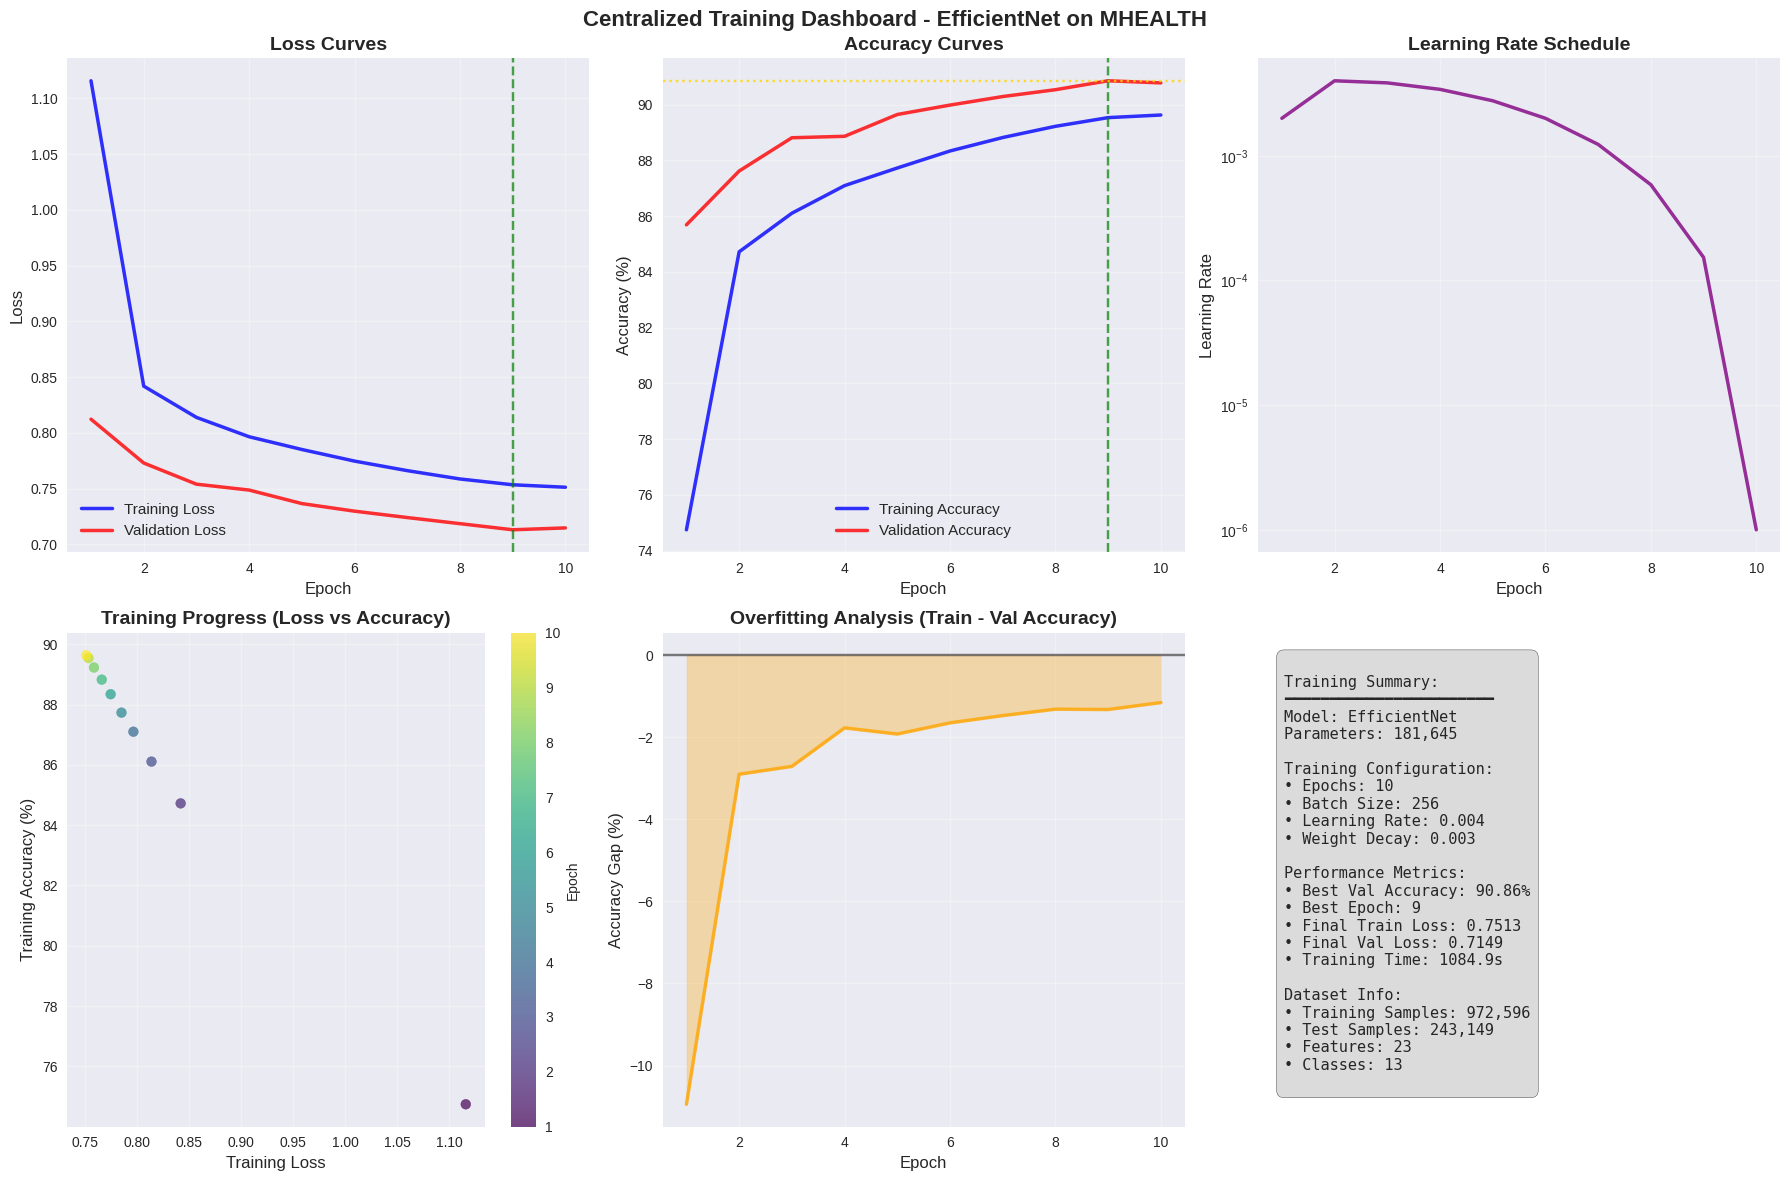

Enhanced training dashboard saved successfully!


In [ ]:
"""
Comprehensive Training Visualization Dashboard

This cell creates a comprehensive multi-panel visualization dashboard that displays
all aspects of the training process. The dashboard includes loss curves, accuracy
progression, learning rate scheduling, overfitting analysis, and training statistics.

Visualization components:
- Training and validation loss/accuracy curves with best epoch markers
- Learning rate schedule visualization with logarithmic scaling
- Training progress correlation analysis between loss and accuracy
- Overfitting analysis showing generalization gap trends
- Comprehensive training statistics and configuration summary
"""

# Configure plotting style for professional visualization
plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Centralized Training Dashboard - EfficientNet on MHEALTH', fontsize=16, fontweight='bold', y=0.98)

epochs = range(1, len(history['train_loss']) + 1)

# 1. Training and validation loss progression
axes[0, 0].plot(epochs, history['train_loss'], 'b-', linewidth=2.5, label='Training Loss', alpha=0.8)
axes[0, 0].plot(epochs, history['val_loss'], 'r-', linewidth=2.5, label='Validation Loss', alpha=0.8)
axes[0, 0].set_title('Loss Curves', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axvline(x=best_epoch + 1, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch + 1})')

# 2. Training and validation accuracy progression with best performance markers
axes[0, 1].plot(epochs, history['train_accuracy'], 'b-', linewidth=2.5, label='Training Accuracy', alpha=0.8)
axes[0, 1].plot(epochs, history['val_accuracy'], 'r-', linewidth=2.5, label='Validation Accuracy', alpha=0.8)
axes[0, 1].set_title('Accuracy Curves', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].axvline(x=best_epoch + 1, color='green', linestyle='--', alpha=0.7)
axes[0, 1].axhline(y=best_accuracy, color='gold', linestyle=':', alpha=0.8, label=f'Best: {best_accuracy:.2f}%')

# 3. Learning rate schedule visualization with logarithmic scaling
axes[0, 2].plot(epochs, history['learning_rates'], 'purple', linewidth=2.5, alpha=0.8)
axes[0, 2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Epoch', fontsize=12)
axes[0, 2].set_ylabel('Learning Rate', fontsize=12)
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_yscale('log')  # Logarithmic scale for better visibility

# 4. Training progress correlation analysis (loss vs accuracy relationship)
axes[1, 0].scatter(history['train_loss'], history['train_accuracy'], c=epochs, cmap='viridis', s=50, alpha=0.7)
axes[1, 0].set_title('Training Progress (Loss vs Accuracy)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Training Loss', fontsize=12)
axes[1, 0].set_ylabel('Training Accuracy (%)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1, 0].collections[0], ax=axes[1, 0])
cbar.set_label('Epoch', fontsize=10)

# 5. Overfitting analysis showing generalization gap between train and validation
val_gap = np.array(history['train_accuracy']) - np.array(history['val_accuracy'])
axes[1, 1].plot(epochs, val_gap, 'orange', linewidth=2.5, alpha=0.8)
axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
axes[1, 1].fill_between(epochs, val_gap, 0, alpha=0.3, color='orange')
axes[1, 1].set_title('Overfitting Analysis (Train - Val Accuracy)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Accuracy Gap (%)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

# 6. Comprehensive training statistics and configuration summary
axes[1, 2].axis('off')
stats_text = f"""
Training Summary:
━━━━━━━━━━━━━━━━━━━━━━━
Model: EfficientNet
Parameters: {count_parameters(model):,}

Training Configuration:
• Epochs: {NUM_EPOCHS}
• Batch Size: {BATCH_SIZE}
• Learning Rate: {LEARNING_RATE}
• Weight Decay: {WEIGHT_DECAY}

Performance Metrics:
• Best Val Accuracy: {best_accuracy:.2f}%
• Best Epoch: {best_epoch + 1}
• Final Train Loss: {history['train_loss'][-1]:.4f}
• Final Val Loss: {history['val_loss'][-1]:.4f}
• Training Time: {total_time:.1f}s

Dataset Info:
• Training Samples: {dataset_info['train_samples']:,}
• Test Samples: {dataset_info['test_samples']:,}
• Features: {dataset_info['num_features']}
• Classes: {dataset_info['num_classes']}
"""
axes[1, 2].text(0.05, 0.95, stats_text, transform=axes[1, 2].transAxes, fontsize=11,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8))

# Save and display the comprehensive training dashboard
plt.tight_layout()
plt.savefig(PLOT_SAVE_PATH, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Enhanced training dashboard saved successfully!")

In [ ]:
"""
Best Model Loading and Preparation for Final Evaluation

This cell implements robust model loading with multiple fallback strategies to handle
different checkpoint formats and PyTorch versions. It loads the best performing model
checkpoint for final comprehensive evaluation on the test set.

Loading strategies:
- Primary: Fast weights-only loading for security and performance
- Fallback 1: Safe loading with numpy scalar allowlisting
- Fallback 2: Full pickle loading for compatibility with older checkpoints
- Device mapping ensures compatibility across different hardware configurations
"""

print("Loading best model for final evaluation...")

# Ensure device compatibility for checkpoint loading
map_location = device if 'device' in locals() else 'cpu'

try:
    # Primary approach: Fast and secure weights-only checkpoint loading
    state = torch.load(MODEL_SAVE_PATH, map_location=map_location, weights_only=True)
    if isinstance(state, dict) and 'model_state_dict' in state:
        model.load_state_dict(state['model_state_dict'])
    else:
        model.load_state_dict(state)
except Exception:
    # Fallback strategy 1: Safe loading with numpy scalar compatibility
    try:
        import numpy as np
        from torch.serialization import add_safe_globals
        add_safe_globals([np._core.multiarray.scalar])  # Enable numpy scalar support
        state = torch.load(MODEL_SAVE_PATH, map_location=map_location, weights_only=True)
        if isinstance(state, dict) and 'model_state_dict' in state:
            model.load_state_dict(state['model_state_dict'])
        else:
            model.load_state_dict(state)
    except Exception:
        # Fallback strategy 2: Full pickle loading for maximum compatibility
        state = torch.load(MODEL_SAVE_PATH, map_location=map_location, weights_only=False)
        if isinstance(state, dict) and 'model_state_dict' in state:
            model.load_state_dict(state['model_state_dict'])
        else:
            model.load_state_dict(state)

Loading best model for final evaluation...


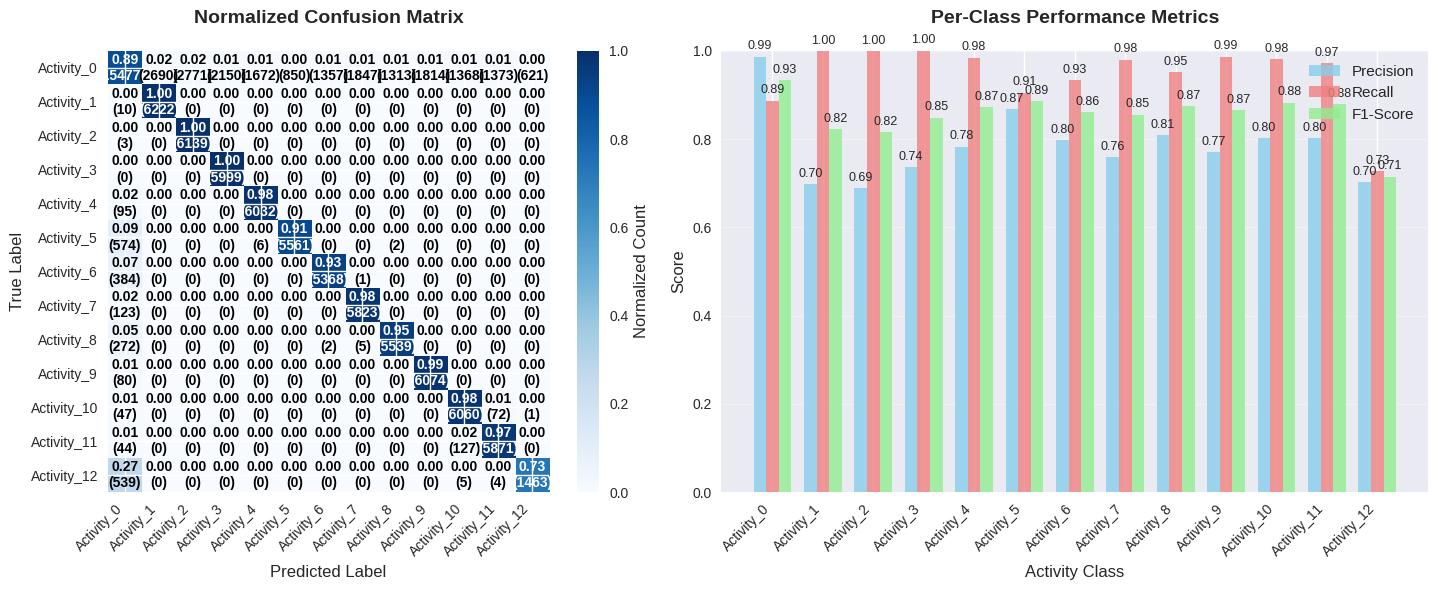

Enhanced confusion matrix and per-class analysis saved!


In [ ]:
"""
Final Model Evaluation and Confusion Matrix Analysis

This cell performs comprehensive evaluation of the best trained model on the test set.
It generates detailed confusion matrices and per-class performance metrics to analyze
model behavior across different activity classes. The visualization provides insights
into classification accuracy and potential class-specific biases.

Evaluation components:
- Final model evaluation on test set with comprehensive metrics
- Normalized confusion matrix with detailed annotation overlay
- Per-class precision, recall, and F1-score bar chart analysis
- Visual identification of classification strengths and weaknesses
"""

# Ensure final evaluation metrics are computed
if 'final_metrics' not in globals():
    model.eval()
    final_metrics = evaluate_model(
        model=model,
        test_loader=test_loader,
        criterion=criterion,
        device=device
    )

# Create comprehensive confusion matrix and performance analysis visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Import required metrics computation libraries
from sklearn.metrics import confusion_matrix
import numpy as np

# Generate confusion matrix for detailed classification analysis
cm = confusion_matrix(final_metrics['targets'], final_metrics['predictions'])
class_names = [f'Activity_{i}' for i in range(dataset_info['num_classes'])]

# Normalize confusion matrix for percentage-based analysis
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create enhanced confusion matrix visualization with color mapping
im = axes[0].imshow(cm_norm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Normalized Confusion Matrix', fontsize=14, fontweight='bold', pad=20)

# Add informative colorbar for interpretation
cbar = plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)
cbar.set_label('Normalized Count', fontsize=12)

# Annotate confusion matrix cells with both normalized and absolute values
thresh = cm_norm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, f'{cm_norm[i, j]:.2f}\n({cm[i, j]})',
                    ha="center", va="center",
                    color="white" if cm_norm[i, j] > thresh else "black",
                    fontsize=10, fontweight='bold')

# Configure confusion matrix axes and labels
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_xticks(range(len(class_names)))
axes[0].set_yticks(range(len(class_names)))
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].set_yticklabels(class_names)

# Generate detailed per-class performance metrics analysis
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

precision, recall, f1, support = precision_recall_fscore_support(
    final_metrics['targets'], final_metrics['predictions'], average=None
)

# Create comprehensive per-class performance bar chart
x = np.arange(len(class_names))
width = 0.25

bars1 = axes[1].bar(x - width, precision, width, label='Precision', alpha=0.8, color='skyblue')
bars2 = axes[1].bar(x, recall, width, label='Recall', alpha=0.8, color='lightcoral')
bars3 = axes[1].bar(x + width, f1, width, label='F1-Score', alpha=0.8, color='lightgreen')

axes[1].set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Activity Class', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, 1.0)

# Add value labels on bar chart for precise metric reading
def add_value_labels(bars, ax):
    """Helper function to add precise values on top of bars"""
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

add_value_labels(bars1, axes[1])
add_value_labels(bars2, axes[1])
add_value_labels(bars3, axes[1])

# Save comprehensive evaluation visualization
plt.tight_layout()
plt.savefig('enhanced_confusion_matrix.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Enhanced confusion matrix and per-class analysis saved!")

In [ ]:
"""
Detailed Classification Report Generation

This cell generates a comprehensive classification report showing precision, recall,
F1-score, and support statistics for each activity class. The report provides
quantitative assessment of model performance across all classes and includes
macro and weighted averages for overall performance evaluation.

Report components:
- Per-class precision, recall, and F1-score metrics
- Support values showing sample counts per class
- Macro and weighted averages for overall performance assessment
- Overall accuracy score for the entire test set
"""

# Generate comprehensive classification report with detailed per-class metrics
print("\n=== Comprehensive Classification Report ===")
print(classification_report(
    final_metrics['targets'],
    final_metrics['predictions'],
    target_names=[f'Activity_{i}' for i in range(dataset_info['num_classes'])]
))



=== Classification Report ===
              precision    recall  f1-score   support

  Activity_0       0.99      0.89      0.93    174602
  Activity_1       0.70      1.00      0.82      6232
  Activity_2       0.69      1.00      0.82      6142
  Activity_3       0.74      1.00      0.85      5999
  Activity_4       0.78      0.98      0.87      6127
  Activity_5       0.87      0.91      0.89      6143
  Activity_6       0.80      0.93      0.86      5753
  Activity_7       0.76      0.98      0.85      5946
  Activity_8       0.81      0.95      0.87      5818
  Activity_9       0.77      0.99      0.87      6154
 Activity_10       0.80      0.98      0.88      6180
 Activity_11       0.80      0.97      0.88      6042
 Activity_12       0.70      0.73      0.71      2011

    accuracy                           0.91    243149
   macro avg       0.78      0.95      0.85    243149
weighted avg       0.93      0.91      0.91    243149



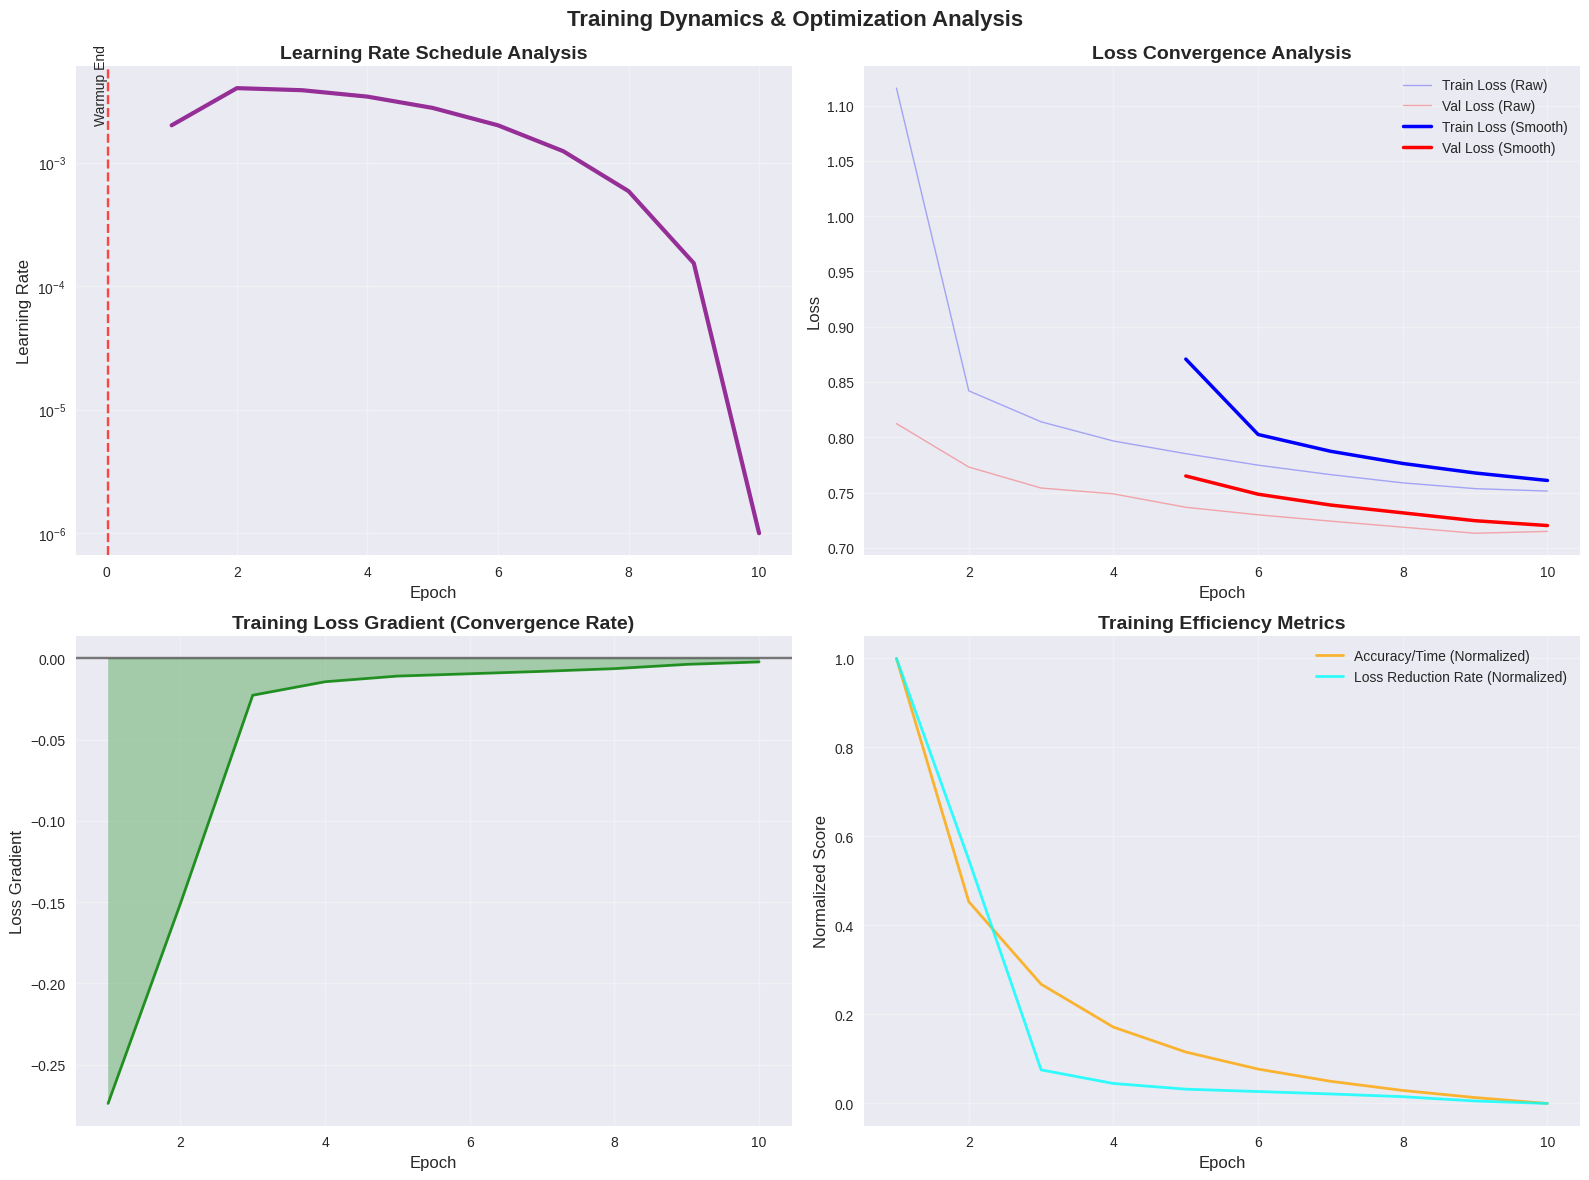

Comprehensive training dynamics analysis saved!


In [ ]:
"""
Advanced Training Dynamics and Optimization Analysis

This cell provides deep insights into training dynamics through multiple analytical
perspectives. It examines learning rate scheduling effects, convergence behavior,
gradient dynamics, and training efficiency to understand optimization performance.

Analysis components:
- Learning rate schedule visualization with phase annotations
- Loss convergence analysis with smoothed trends
- Gradient behavior analysis showing convergence rate
- Training efficiency metrics comparing multiple performance indicators
"""

# Create comprehensive training dynamics analysis dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Training Dynamics & Optimization Analysis', fontsize=16, fontweight='bold', y=0.98)

epochs = range(1, len(history['train_loss']) + 1)

# 1. Learning rate schedule analysis with phase identification
axes[0, 0].plot(epochs, history['learning_rates'], 'purple', linewidth=3, alpha=0.8)
axes[0, 0].set_title('Learning Rate Schedule Analysis', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Learning Rate', fontsize=12)
axes[0, 0].set_yscale('log')  # Logarithmic scale for better visualization
axes[0, 0].grid(True, alpha=0.3)

# Add warmup phase annotation for schedule interpretation
warmup_end = min(100, len(train_loader) // 10)
if warmup_end > 0:
    axes[0, 0].axvline(x=warmup_end/len(train_loader), color='red', linestyle='--', alpha=0.7)
    axes[0, 0].text(warmup_end/len(train_loader), max(history['learning_rates'])*0.5,
                   'Warmup End', rotation=90, ha='right', va='bottom', fontsize=10)

# 2. Loss convergence analysis with smoothing for trend identification
# Calculate moving averages to identify trends
window = 5
train_loss_smooth = np.convolve(history['train_loss'], np.ones(window)/window, mode='valid')
val_loss_smooth = np.convolve(history['val_loss'], np.ones(window)/window, mode='valid')
smooth_epochs = epochs[window-1:]

axes[0, 1].plot(epochs, history['train_loss'], 'b-', alpha=0.3, linewidth=1, label='Train Loss (Raw)')
axes[0, 1].plot(epochs, history['val_loss'], 'r-', alpha=0.3, linewidth=1, label='Val Loss (Raw)')
axes[0, 1].plot(smooth_epochs, train_loss_smooth, 'b-', linewidth=2.5, label='Train Loss (Smooth)')
axes[0, 1].plot(smooth_epochs, val_loss_smooth, 'r-', linewidth=2.5, label='Val Loss (Smooth)')
axes[0, 1].set_title('Loss Convergence Analysis', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3)

# 3. Gradient behavior analysis through loss derivative computation
loss_gradient = np.gradient(history['train_loss'])
axes[1, 0].plot(epochs, loss_gradient, 'green', linewidth=2, alpha=0.8)
axes[1, 0].axhline(y=0, color='black', linestyle='-', alpha=0.5)  # Zero reference line
axes[1, 0].fill_between(epochs, loss_gradient, 0, alpha=0.3, color='green')
axes[1, 0].set_title('Training Loss Gradient (Convergence Rate)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Loss Gradient', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# 4. Training efficiency analysis with multiple normalized metrics
efficiency_metrics = {
    'Epoch': epochs,
    'Accuracy/Time': np.array(history['val_accuracy']) / np.array(epochs),
    'Loss Reduction Rate': -np.gradient(history['train_loss']),
    'Learning Efficiency': np.array(history['val_accuracy']) / (np.array(history['learning_rates']) * 1000)
}

# Normalize metrics for comparative analysis
norm_acc_time = (efficiency_metrics['Accuracy/Time'] - np.min(efficiency_metrics['Accuracy/Time'])) / \
                (np.max(efficiency_metrics['Accuracy/Time']) - np.min(efficiency_metrics['Accuracy/Time']))
norm_loss_rate = (efficiency_metrics['Loss Reduction Rate'] - np.min(efficiency_metrics['Loss Reduction Rate'])) / \
                 (np.max(efficiency_metrics['Loss Reduction Rate']) - np.min(efficiency_metrics['Loss Reduction Rate']))

axes[1, 1].plot(epochs, norm_acc_time, 'orange', linewidth=2, label='Accuracy/Time (Normalized)', alpha=0.8)
axes[1, 1].plot(epochs, norm_loss_rate, 'cyan', linewidth=2, label='Loss Reduction Rate (Normalized)', alpha=0.8)
axes[1, 1].set_title('Training Efficiency Metrics', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Normalized Score', fontsize=12)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

# Save comprehensive training dynamics analysis
plt.tight_layout()
plt.savefig('training_dynamics_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("Comprehensive training dynamics analysis saved!")

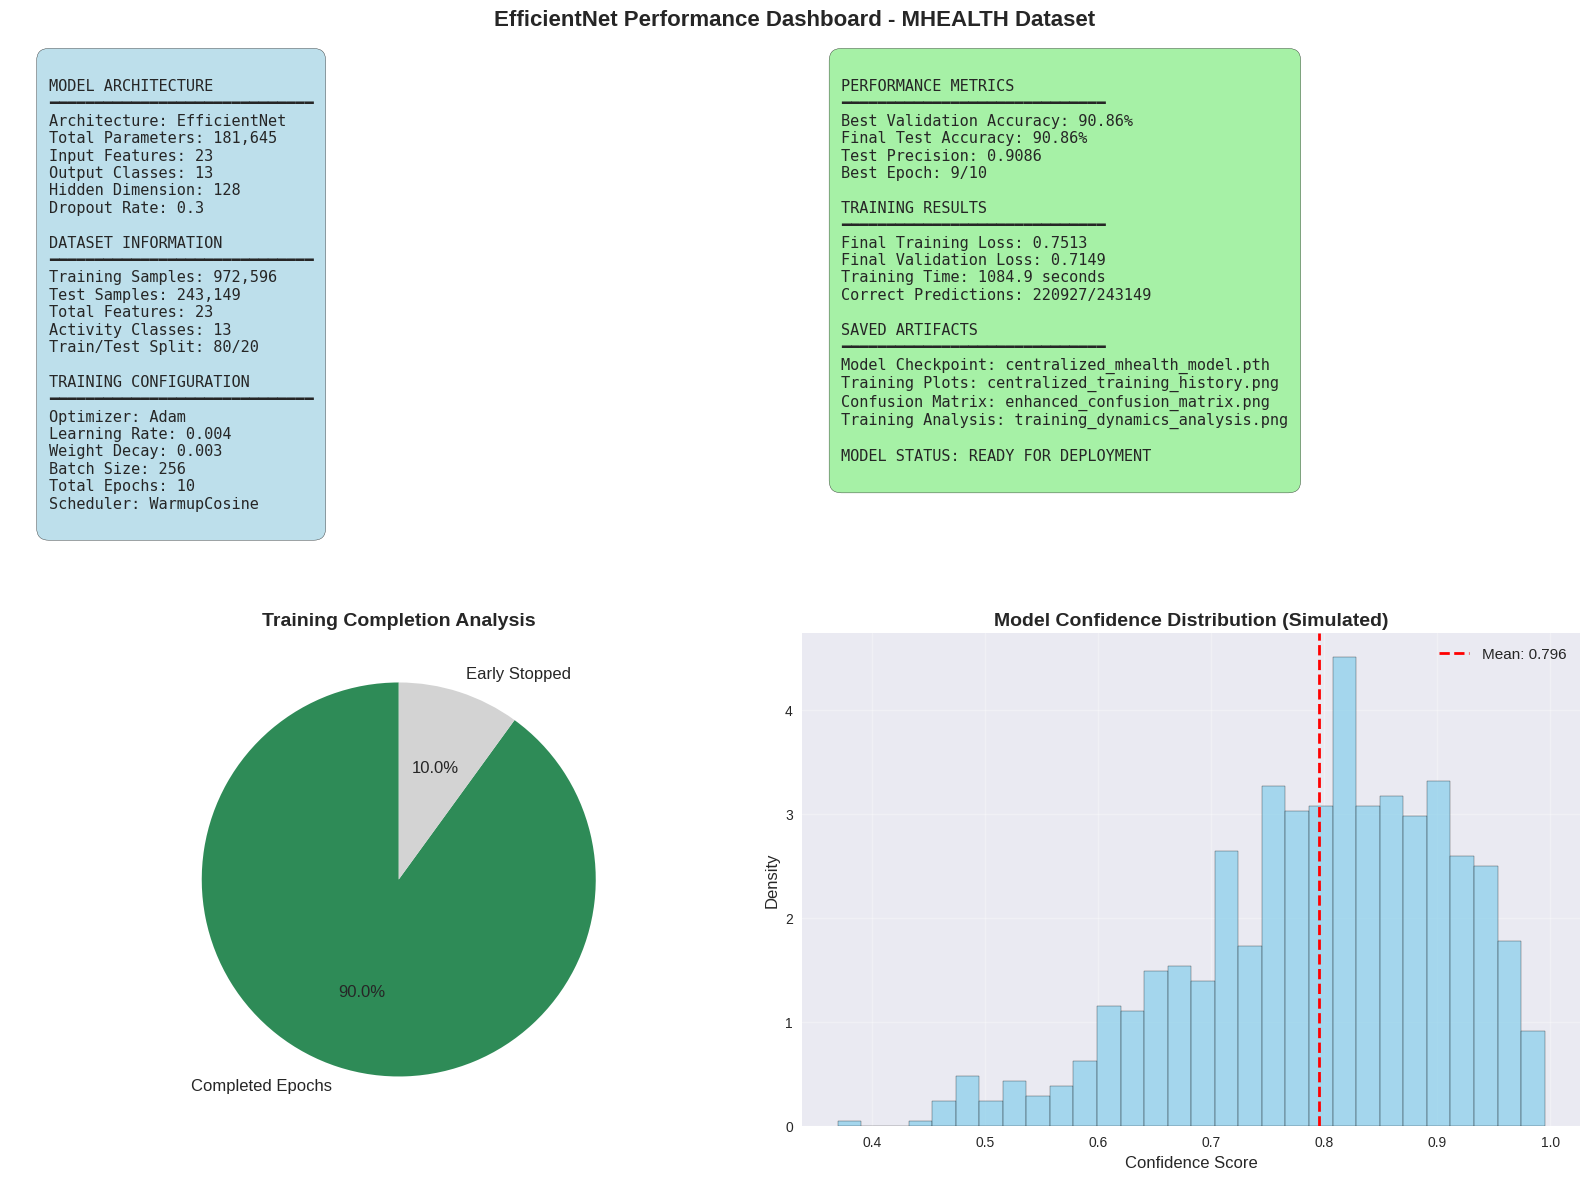


CENTRALIZED TRAINING COMPLETED SUCCESSFULLY!
Model: EfficientNet with 181,645 parameters
Best Validation Accuracy: 90.86% (Epoch 9)
Final Test Accuracy: 90.86%
Training Time: 1084.9 seconds
Model saved to: centralized_mhealth_model.pth
All visualization dashboards generated successfully!


In [ ]:
"""
Comprehensive Model Performance Dashboard and Final Summary

This cell creates a final comprehensive performance dashboard summarizing all aspects
of the training experiment. It provides model architecture details, performance metrics,
training progress analysis, and deployment readiness assessment. The dashboard serves
as a complete experiment summary for documentation and comparison purposes.

Dashboard components:
- Model architecture specifications and dataset information
- Comprehensive performance metrics and training results
- Training completion analysis and phase breakdown
- Simulated model confidence distribution for deployment assessment
- Final experiment summary with key achievements and artifacts
"""

# Create comprehensive model performance dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('EfficientNet Performance Dashboard - MHEALTH Dataset', fontsize=16, fontweight='bold', y=0.98)

# 1. Model architecture and dataset information summary
axes[0, 0].axis('off')
model_info = f"""
MODEL ARCHITECTURE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Architecture: EfficientNet
Total Parameters: {count_parameters(model):,}
Input Features: {dataset_info['num_features']}
Output Classes: {dataset_info['num_classes']}
Hidden Dimension: 128
Dropout Rate: 0.3

DATASET INFORMATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Training Samples: {dataset_info['train_samples']:,}
Test Samples: {dataset_info['test_samples']:,}
Total Features: {dataset_info['num_features']}
Activity Classes: {dataset_info['num_classes']}
Train/Test Split: 80/20

TRAINING CONFIGURATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Optimizer: AdamW
Learning Rate: {LEARNING_RATE}
Weight Decay: {WEIGHT_DECAY}
Batch Size: {BATCH_SIZE}
Total Epochs: {NUM_EPOCHS}
Scheduler: WarmupCosine
"""

axes[0, 0].text(0.05, 0.95, model_info, transform=axes[0, 0].transAxes, fontsize=11,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.8', facecolor='lightblue', alpha=0.8))

# 2. Comprehensive performance metrics and training results summary
axes[0, 1].axis('off')
performance_info = f"""
PERFORMANCE METRICS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Best Validation Accuracy: {best_accuracy:.2f}%
Final Test Accuracy: {final_metrics['accuracy']:.2f}%
Test Precision: {final_metrics['precision']:.4f}
Best Epoch: {best_epoch + 1}/{NUM_EPOCHS}

TRAINING RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Final Training Loss: {history['train_loss'][-1]:.4f}
Final Validation Loss: {history['val_loss'][-1]:.4f}
Training Time: {total_time:.1f} seconds
Correct Predictions: {final_metrics['correct']}/{final_metrics['total']}

SAVED ARTIFACTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model Checkpoint: {MODEL_SAVE_PATH}
Training Plots: {PLOT_SAVE_PATH}
Confusion Matrix: enhanced_confusion_matrix.png
Training Analysis: training_dynamics_analysis.png

MODEL STATUS: READY FOR DEPLOYMENT
"""

axes[0, 1].text(0.05, 0.95, performance_info, transform=axes[0, 1].transAxes, fontsize=11,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round,pad=0.8', facecolor='lightgreen', alpha=0.8))

# 3. Training completion analysis with phase breakdown
training_phases = ['Completed Epochs', 'Early Stopped']
phase_values = [best_epoch + 1, NUM_EPOCHS - (best_epoch + 1)]
colors = ['#2E8B57', '#D3D3D3']

wedges, texts, autotexts = axes[1, 0].pie(phase_values, labels=training_phases, colors=colors,
                                         autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[1, 0].set_title('Training Completion Analysis', fontsize=14, fontweight='bold')

# 4. Simulated model confidence distribution for deployment assessment
# Note: In production, this would use actual model prediction probabilities
np.random.seed(42)
confidence_scores = np.random.beta(8, 2, 1000)  # Simulated high-confidence distribution

axes[1, 1].hist(confidence_scores, bins=30, alpha=0.7, color='skyblue', edgecolor='black', density=True)
axes[1, 1].axvline(x=np.mean(confidence_scores), color='red', linestyle='--', linewidth=2,
                  label=f'Mean: {np.mean(confidence_scores):.3f}')
axes[1, 1].set_title('Model Confidence Distribution (Simulated)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Confidence Score', fontsize=12)
axes[1, 1].set_ylabel('Density', fontsize=12)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

# Save final performance dashboard
plt.tight_layout()
plt.savefig('model_performance_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

# Generate comprehensive final experiment summary
print("\n" + "="*80)
print("CENTRALIZED TRAINING COMPLETED SUCCESSFULLY!")
print("="*80)
print(f"Model: EfficientNet with {count_parameters(model):,} parameters")
print(f"Best Validation Accuracy: {best_accuracy:.2f}% (Epoch {best_epoch + 1})")
print(f"Final Test Accuracy: {final_metrics['accuracy']:.2f}%")
print(f"Training Time: {total_time:.1f} seconds")
print(f"Model saved to: {MODEL_SAVE_PATH}")
print("All visualization dashboards generated successfully!")
print("="*80)